In [1]:
from dotenv import load_dotenv

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage

from langgraph.graph  import StateGraph, START,END,MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

1. Creating Long Term Message Store + seed memories [ before running graph]

In [2]:
store = InMemoryStore()

user_id = "u1"

In [3]:
# Store user details as a single blob
user_details = ("user",user_id,"details")

In [4]:
store.put(user_details,"profile-1",{"data":"Name: Nazia"})
store.put(user_details, "profile_2", {"data": "Profession: Software Developer and AI enthusiast"})
store.put(user_details, "preference_1", {"data": "Prefers concise answers"})
store.put(user_details, "preference_2", {"data": "Likes examples in Python"})
store.put(user_details, "project_1", {"data": "Building MCP servers (Python-based project)"})

2. System prompt template (your prompt)

In [10]:
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Nazia...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..." 
say "Since your project is built with TypeScript..."

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""


3. Build graph: START -> chat -> END (read-only LTM)

In [5]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [11]:
def chat_node(state:MessagesState,config = RunnableConfig,store=BaseStore):
    user_id = config["configurable"]["user_id"]
    
    # Read-only: fetch user details memory (no writes)
    user_details = ("user",user_id,"details")
    items = store.search(user_details)
    
    # Convert memory items into a string blob for {user_details_content}
    if items:
        user_details_content = "\n".join(f"- {it.value.get('data', '')}" for it in items)
    else:
        user_details_content = ""  # prompt says it may be empty
        
    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(
        user_details_content=user_details_content
    )
    system_message = SystemMessage(content = system_prompt)
    response = llm.invoke([system_message]+state['messages'])
    return {'messages':[response]}

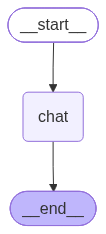

In [12]:
builder = StateGraph(MessagesState)
builder.add_node('chat',chat_node)
builder.add_edge(START,'chat')
builder.add_edge('chat',END)

graph = builder.compile(store= store)

graph

4. Run it (provide user_id in config)

In [13]:
config = {"configurable": {"user_id": "u1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Explain gen ai in simple terms."}]},
    config,
)

print(result["messages"][-1].content)

Hey Nazia!

As a fellow software developer and AI enthusiast, you'll find Generative AI (Gen AI) pretty fascinating.

In simple terms, **Generative AI is a type of artificial intelligence that can create new, original content, rather than just analyzing or classifying existing data.**

Think of it like this:
*   Most traditional AI might tell you if a picture contains a cat (discriminative AI).
*   **Generative AI**, however, can *draw a brand new picture of a cat* that's never existed before!

It learns patterns, structures, and styles from massive amounts of existing data (like text, images, code, or audio). Once it understands these patterns, it can then generate completely new outputs that are similar in style and content to what it learned, but are unique creations.

For your Python-based MCP server project, Nazia, imagine an AI that could:
*   Generate new Python code snippets for server functions.
*   Create unique textures or 3D models for your game world.
*   Even write new qu